In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set paths
dir1 = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2/partial_fit_5std")
dir2 = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2_T2_5std")
output_dir = Path("/data484_4/txia2/mocov2")
output_dir.mkdir(parents=True, exist_ok=True)

print("Loading feature files from both directories...")


/home/txia2/miniconda3/envs/deependo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading feature files from both directories...


In [2]:
# Load all Feature files from directory 1
feature_files_1 = sorted(glob.glob(str(dir1 / "Feature_*.csv")))
print(f"Found {len(feature_files_1)} feature files in directory 1")

# Load all Feature files from directory 2
feature_files_2 = sorted(glob.glob(str(dir2 / "Feature_*.csv")))
print(f"Found {len(feature_files_2)} feature files in directory 2")

# Load and combine features from directory 1
data_dict_1 = {}
for file_path in tqdm(feature_files_1, desc="Loading dir1 features"):
    df = pd.read_csv(file_path, sep='\t')
    # Get the feature column name (pca_* or feature_* pattern)
    # Exclude FID and IID, get the numeric feature column
    feature_cols = [col for col in df.columns if col not in ['FID', 'IID'] and (col.startswith('pca_') or col.startswith('feature_'))]
    if not feature_cols:
        # If no pattern match, get first numeric column that's not FID or IID
        feature_cols = [col for col in df.columns if col not in ['FID', 'IID']]
    if feature_cols and 'IID' in df.columns:
        feature_col = feature_cols[0]
        data_dict_1[feature_col] = df.set_index('IID')[feature_col]

# Load and combine features from directory 2
data_dict_2 = {}
for file_path in tqdm(feature_files_2, desc="Loading dir2 features"):
    df = pd.read_csv(file_path, sep='\t')
    # Get the feature column name (pca_* or feature_* pattern)
    # Exclude FID and IID, get the numeric feature column
    feature_cols = [col for col in df.columns if col not in ['FID', 'IID'] and (col.startswith('pca_') or col.startswith('feature_'))]
    if not feature_cols:
        # If no pattern match, get first numeric column that's not FID or IID
        feature_cols = [col for col in df.columns if col not in ['FID', 'IID']]
    if feature_cols and 'IID' in df.columns:
        feature_col = feature_cols[0]
        data_dict_2[feature_col] = df.set_index('IID')[feature_col]

print(f"\nDirectory 1: {len(data_dict_1)} features")
print(f"Directory 2: {len(data_dict_2)} features")


Found 128 feature files in directory 1
Found 128 feature files in directory 2


Loading dir2 features: 100%|██████████| 128/128 [00:00<00:00, 164.93it/s]


Directory 1: 128 features
Directory 2: 128 features


In [3]:
# Combine features into dataframes
df1 = pd.DataFrame(data_dict_1)
df2 = pd.DataFrame(data_dict_2)

print(f"Directory 1 shape: {df1.shape}")
print(f"Directory 2 shape: {df2.shape}")

# Find common samples (IIDs)
common_iids = df1.index.intersection(df2.index)
print(f"\nCommon samples (IIDs): {len(common_iids)}")

# Filter to common samples
df1_common = df1.loc[common_iids]
df2_common = df2.loc[common_iids]

# Remove samples with any NA values
df1_clean = df1_common.dropna()
df2_clean = df2_common.dropna()

# Find samples that have no NA in both datasets
final_common_iids = df1_clean.index.intersection(df2_clean.index)
print(f"Samples without NA in both datasets: {len(final_common_iids)}")

# Get final clean data
df1_final = df1_clean.loc[final_common_iids]
df2_final = df2_clean.loc[final_common_iids]

print(f"\nFinal data shapes:")
print(f"Directory 1: {df1_final.shape}")
print(f"Directory 2: {df2_final.shape}")


Directory 1 shape: (22985, 128)
Directory 2 shape: (22985, 128)

Common samples (IIDs): 22985
Samples without NA in both datasets: 22619

Final data shapes:
Directory 1: (22619, 128)
Directory 2: (22619, 128)


In [4]:
# Keep features separate - don't merge them
# We'll compute t-SNE on T1 features and T2 features separately
# and then plot them with different colors

X_t1 = df1_final.values  # T1 features (128 dimensions)
X_t2 = df2_final.values  # T2 features (128 dimensions)

print(f"T1 feature matrix shape: {X_t1.shape}")
print(f"T2 feature matrix shape: {X_t2.shape}")
print(f"\nNote: Using separate feature sets, not merged into 256 dimensions")


T1 feature matrix shape: (22619, 128)
T2 feature matrix shape: (22619, 128)

Note: Using separate feature sets, not merged into 256 dimensions


In [5]:
# Fit UMAP on T1 features, then transform both T1 and T2
# This ensures both are in the same embedding space
print("Fitting UMAP on T1 features...")
umap_model = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1, verbose=True)
X_umap_t1 = umap_model.fit_transform(X_t1)

print(f"\nTransforming T2 features using the fitted UMAP model...")
X_umap_t2 = umap_model.transform(X_t2)

print(f"\nT1 UMAP embedding shape: {X_umap_t1.shape}")
print(f"T2 UMAP embedding shape: {X_umap_t2.shape}")


/home/txia2/miniconda3/envs/deependo/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP on T1 features...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Thu Dec  4 20:21:42 2025 Construct fuzzy simplicial set
Thu Dec  4 20:21:42 2025 Finding Nearest Neighbors
Thu Dec  4 20:21:42 2025 Building RP forest with 13 trees


Thu Dec  4 20:21:46 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Thu Dec  4 20:21:54 2025 Finished Nearest Neighbor Search
Thu Dec  4 20:21:56 2025 Construct embedding


Epochs completed:   2%| ▎          5/200 [00:00]

	completed  0  /  200 epochs


...

	completed  24  /  30 epochs


Epochs completed:  97%| █████████▋ 29/30 [00:02]

	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:02]


T1 UMAP embedding shape: (22619, 2)
T2 UMAP embedding shape: (22619, 2)



Plot saved to: /data484_4/txia2/mocov2/umap_embedding_t1_t2.png


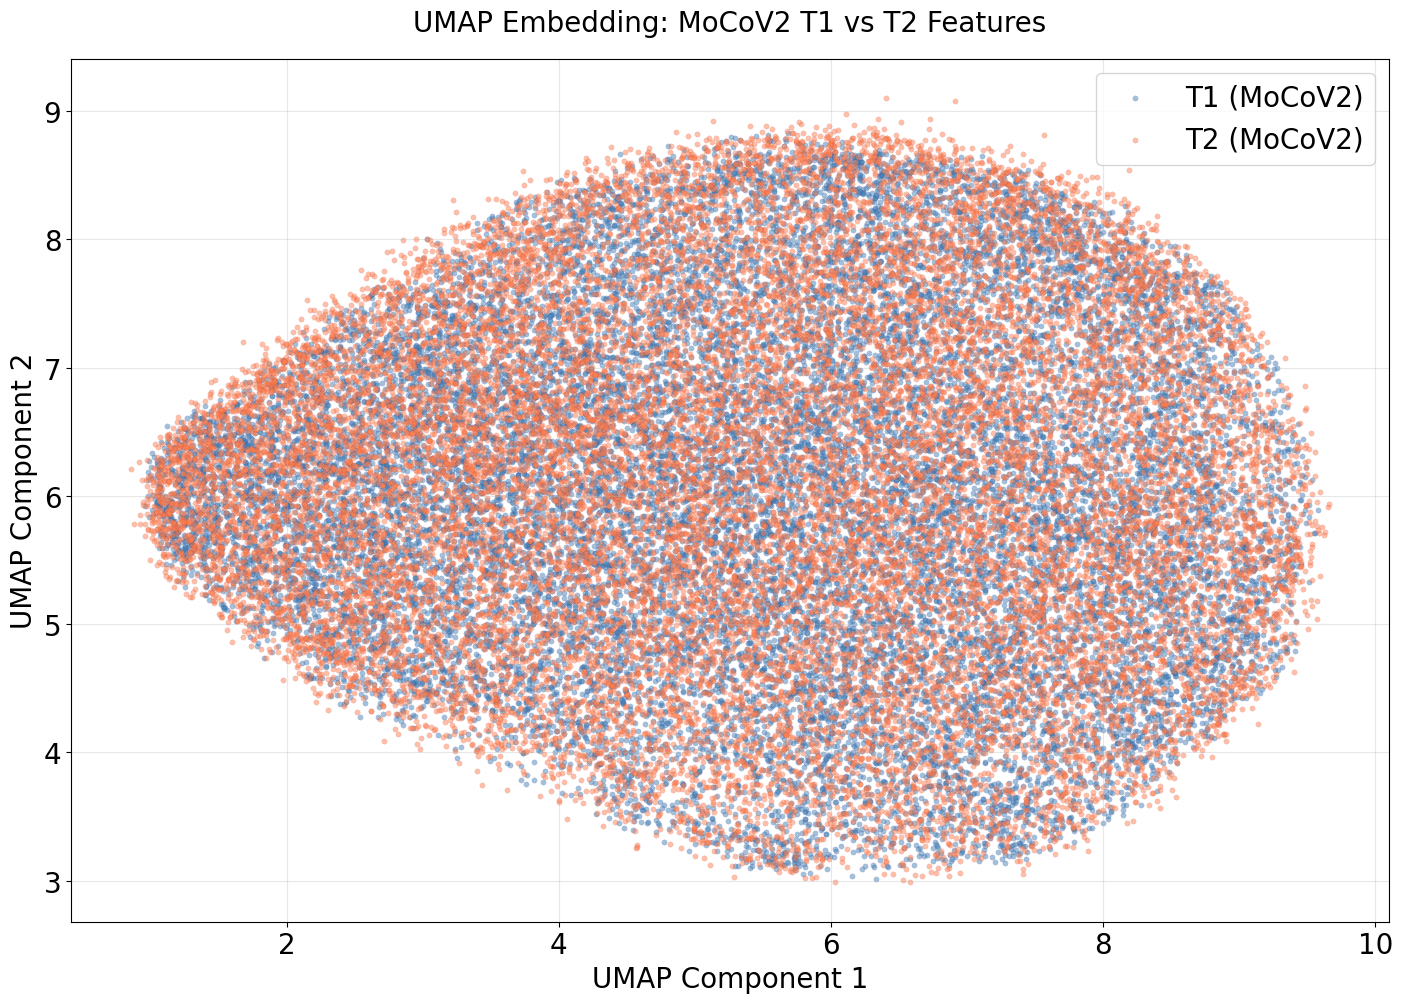

In [8]:
# Create visualization with T1 and T2 colored differently
plt.figure(figsize=(14, 10))

# Plot T1 samples in blue
plt.scatter(X_umap_t1[:, 0], X_umap_t1[:, 1], alpha=0.5, s=15, 
            c='steelblue', label='T1 (MoCoV2)', edgecolors='darkblue', linewidths=0.1)

# Plot T2 samples in red
plt.scatter(X_umap_t2[:, 0], X_umap_t2[:, 1], alpha=0.5, s=15, 
            c='coral', label='T2 (MoCoV2)', edgecolors='darkred', linewidths=0.1)

plt.xlabel('UMAP Component 1', fontsize=20)
plt.ylabel('UMAP Component 2', fontsize=20)
plt.title('UMAP Embedding: MoCoV2 T1 vs T2 Features', fontsize=20, pad=20)
plt.legend(fontsize=20, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Save the plot
output_path = output_dir / 'umap_embedding_t1_t2.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {output_path}")
plt.show()


In [7]:
# Save the UMAP coordinates for both T1 and T2
umap_df = pd.DataFrame({
    'IID': final_common_iids,
    'umap_t1_1': X_umap_t1[:, 0],
    'umap_t1_2': X_umap_t1[:, 1],
    'umap_t2_1': X_umap_t2[:, 0],
    'umap_t2_2': X_umap_t2[:, 1]
})

output_csv = output_dir / 'umap_embedding_coordinates_t1_t2.csv'
umap_df.to_csv(output_csv, index=False)
print(f"UMAP coordinates saved to: {output_csv}")

# Print summary statistics
print(f"\n=== Summary ===")
print(f"Total samples in embeddings: {len(final_common_iids)}")
print(f"T1 features: {X_t1.shape[1]} dimensions")
print(f"T2 features: {X_t2.shape[1]} dimensions")
print(f"\nUMAP parameters:")
print(f"  - n_neighbors: 30")
print(f"  - min_dist: 0.1")
print(f"  - n_components: 2")
print(f"  - Random state: 42")
print(f"  - Fitted on T1, transformed on T2 (same embedding space)")


UMAP coordinates saved to: /data484_4/txia2/mocov2/umap_embedding_coordinates_t1_t2.csv

=== Summary ===
Total samples in embeddings: 22619
T1 features: 128 dimensions
T2 features: 128 dimensions

UMAP parameters:
  - n_neighbors: 30
  - min_dist: 0.1
  - n_components: 2
  - Random state: 42
  - Fitted on T1, transformed on T2 (same embedding space)
